In [3]:
# import pandas as pd
# import numpy as np
# from scipy.interpolate import interp1d
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report
# import pickle
# import os

# def load_empatica_data(subject_id):
#     base_path = f'WESAD/{subject_id}/{subject_id}_E4_Data/'
#     acc = pd.read_csv(base_path + 'ACC.csv', header=None)
#     bvp = pd.read_csv(base_path + 'BVP.csv', header=None)
#     eda = pd.read_csv(base_path + 'EDA.csv', header=None)
#     hr = pd.read_csv(base_path + 'HR.csv', header=None)
#     temp = pd.read_csv(base_path + 'TEMP.csv', header=None)
#     return acc, bvp, eda, hr, temp

# def generate_timestamps(start_time, sampling_rate, length):
#     return start_time + np.arange(length) / sampling_rate

# def process_sensor_data(df, column_names):
#     start_time = df.iloc[0, 0]  # Initial timestamp
#     sampling_rate = df.iloc[1, 0]  # Sampling rate
#     df = df.iloc[2:]  # Actual data starts from the third row
#     df.columns = column_names
#     df.reset_index(drop=True, inplace=True)
#     timestamps = generate_timestamps(start_time, sampling_rate, len(df))
#     df = df.copy()
#     df.loc[:, 'timestamp'] = timestamps
#     return df

# def preprocess_data(acc, bvp, eda, hr, temp):
#     acc = process_sensor_data(acc, ['X', 'Y', 'Z'])
#     bvp = process_sensor_data(bvp, ['BVP'])
#     eda = process_sensor_data(eda, ['EDA'])
#     hr = process_sensor_data(hr, ['HR'])
#     temp = process_sensor_data(temp, ['TEMP'])

#     print(f"acc shape after processing: {acc.shape}")
#     print(f"bvp shape after processing: {bvp.shape}")
#     print(f"eda shape after processing: {eda.shape}")
#     print(f"hr shape after processing: {hr.shape}")
#     print(f"temp shape after processing: {temp.shape}")

#     min_timestamp = max(acc['timestamp'].min(), bvp['timestamp'].min(), eda['timestamp'].min(), hr['timestamp'].min(), temp['timestamp'].min())
#     max_timestamp = min(acc['timestamp'].max(), bvp['timestamp'].max(), eda['timestamp'].max(), hr['timestamp'].max(), temp['timestamp'].max())

#     common_timestamps = np.arange(min_timestamp, max_timestamp, 1)  # 1 second intervals, adjust as necessary

#     def interpolate(df, timestamps):
#         if df.shape[0] > 1:
#             interp_func = interp1d(df['timestamp'], df.iloc[:, :-1], axis=0, fill_value="extrapolate")
#             interpolated_data = interp_func(timestamps)
#             return pd.DataFrame(interpolated_data, columns=df.columns[:-1], index=timestamps)
#         else:
#             return pd.DataFrame(columns=df.columns[:-1])

#     acc_interpolated = interpolate(acc, common_timestamps)
#     bvp_interpolated = interpolate(bvp, common_timestamps)
#     eda_interpolated = interpolate(eda, common_timestamps)
#     hr_interpolated = interpolate(hr, common_timestamps)
#     temp_interpolated = interpolate(temp, common_timestamps)

#     print(f"acc shape after interpolation: {acc_interpolated.shape}")
#     print(f"bvp shape after interpolation: {bvp_interpolated.shape}")
#     print(f"eda shape after interpolation: {eda_interpolated.shape}")
#     print(f"hr shape after interpolation: {hr_interpolated.shape}")
#     print(f"temp shape after interpolation: {temp_interpolated.shape}")

#     combined_data = pd.concat([acc_interpolated, bvp_interpolated, eda_interpolated, hr_interpolated, temp_interpolated], axis=1)
#     combined_data.ffill(inplace=True)
    
#     print(f"combined_data shape: {combined_data.shape}")

#     return combined_data

# def load_labels(subject_id):
#     with open(f'WESAD/{subject_id}/{subject_id}.pkl', 'rb') as file:
#         pkl_data = pickle.load(file, encoding="latin1")
#         labels = pkl_data['label']
#         timestamps = np.arange(len(labels))
#         label_df = pd.DataFrame({'timestamp': timestamps, 'label': labels})
#     return label_df

# def preprocess_all_subjects(subject_ids):
#     all_data = []
#     for subject_id in subject_ids:
#         acc, bvp, eda, hr, temp = load_empatica_data(subject_id)
#         combined_data = preprocess_data(acc, bvp, eda, hr, temp)

#         labels = load_labels(subject_id)
#         labels_interpolated = np.interp(combined_data.index, labels['timestamp'], labels['label'])
#         combined_data['label'] = labels_interpolated

#         combined_data['subject'] = subject_id

#         all_data.append(combined_data)
#         print(f"Preprocessed data for {subject_id} completed.")

#     all_data_combined = pd.concat(all_data, ignore_index=True)

#     return all_data_combined

# subject_ids = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
# all_data_combined = preprocess_all_subjects(subject_ids)

# filtered_data = all_data_combined[all_data_combined['label'].isin([1, 2])]
# filtered_data['label'] = np.where(filtered_data['label'] == 2, 1, 0)

# features = filtered_data.drop(columns=['label', 'subject'])
# labels = filtered_data['label']

# scaler = StandardScaler()
# features_scaled = scaler.fit_transform(features)

# X_train, X_test, y_train, y_test = train_test_split(features_scaled, labels, test_size=0.2, random_state=42)

# svm_model = SVC(kernel='linear', random_state=42)
# svm_model.fit(X_train, y_train)

# y_pred = svm_model.predict(X_test)
# accuracy = accuracy_score(y_test, y_pred)
# report = classification_report(y_test, y_pred)

# print(f"Accuracy: {accuracy}")
# print("Classification Report:")
# print(report)


acc shape after processing: (251970, 4)
bvp shape after processing: (503943, 2)
eda shape after processing: (31494, 2)
hr shape after processing: (7865, 2)
temp shape after processing: (31496, 2)
acc shape after interpolation: (7864, 3)
bvp shape after interpolation: (7864, 1)
eda shape after interpolation: (7864, 1)
hr shape after interpolation: (7864, 1)
temp shape after interpolation: (7864, 1)
combined_data shape: (7864, 7)
Preprocessed data for S2 completed.
acc shape after processing: (247152, 4)
bvp shape after processing: (494307, 2)
eda shape after processing: (30894, 2)
hr shape after processing: (7714, 2)
temp shape after processing: (30888, 2)
acc shape after interpolation: (7712, 3)
bvp shape after interpolation: (7712, 1)
eda shape after interpolation: (7712, 1)
hr shape after interpolation: (7712, 1)
temp shape after interpolation: (7712, 1)
combined_data shape: (7712, 7)
Preprocessed data for S3 completed.
acc shape after processing: (255978, 4)
bvp shape after processi

ValueError: Found array with 0 sample(s) (shape=(0, 7)) while a minimum of 1 is required by StandardScaler.

In [5]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import pickle
import os

def load_empatica_data(subject_id):
    base_path = f'WESAD/{subject_id}/{subject_id}_E4_Data/'
    acc = pd.read_csv(base_path + 'ACC.csv', header=None)
    bvp = pd.read_csv(base_path + 'BVP.csv', header=None)
    eda = pd.read_csv(base_path + 'EDA.csv', header=None)
    hr = pd.read_csv(base_path + 'HR.csv', header=None)
    temp = pd.read_csv(base_path + 'TEMP.csv', header=None)
    return acc, bvp, eda, hr, temp

def generate_timestamps(start_time, sampling_rate, length):
    return start_time + np.arange(length) / sampling_rate

def process_sensor_data(df, column_names):
    start_time = df.iloc[0, 0]  # Initial timestamp
    sampling_rate = df.iloc[1, 0]  # Sampling rate
    df = df.iloc[2:]  # Actual data starts from the third row
    df.columns = column_names
    df.reset_index(drop=True, inplace=True)
    timestamps = generate_timestamps(start_time, sampling_rate, len(df))
    df = df.copy()
    df.loc[:, 'timestamp'] = timestamps
    return df

def preprocess_data(acc, bvp, eda, hr, temp):
    acc = process_sensor_data(acc, ['X', 'Y', 'Z'])
    bvp = process_sensor_data(bvp, ['BVP'])
    eda = process_sensor_data(eda, ['EDA'])
    hr = process_sensor_data(hr, ['HR'])
    temp = process_sensor_data(temp, ['TEMP'])

    print(f"acc shape after processing: {acc.shape}")
    print(f"bvp shape after processing: {bvp.shape}")
    print(f"eda shape after processing: {eda.shape}")
    print(f"hr shape after processing: {hr.shape}")
    print(f"temp shape after processing: {temp.shape}")

    min_timestamp = max(acc['timestamp'].min(), bvp['timestamp'].min(), eda['timestamp'].min(), hr['timestamp'].min(), temp['timestamp'].min())
    max_timestamp = min(acc['timestamp'].max(), bvp['timestamp'].max(), eda['timestamp'].max(), hr['timestamp'].max(), temp['timestamp'].max())

    common_timestamps = np.arange(min_timestamp, max_timestamp, 1) 

    def interpolate(df, timestamps):
        if df.shape[0] > 1:
            interp_func = interp1d(df['timestamp'], df.iloc[:, :-1], axis=0, fill_value="extrapolate")
            interpolated_data = interp_func(timestamps)
            return pd.DataFrame(interpolated_data, columns=df.columns[:-1], index=timestamps)
        else:
            return pd.DataFrame(columns=df.columns[:-1])

    acc_interpolated = interpolate(acc, common_timestamps)
    bvp_interpolated = interpolate(bvp, common_timestamps)
    eda_interpolated = interpolate(eda, common_timestamps)
    hr_interpolated = interpolate(hr, common_timestamps)
    temp_interpolated = interpolate(temp, common_timestamps)

    print(f"acc shape after interpolation: {acc_interpolated.shape}")
    print(f"bvp shape after interpolation: {bvp_interpolated.shape}")
    print(f"eda shape after interpolation: {eda_interpolated.shape}")
    print(f"hr shape after interpolation: {hr_interpolated.shape}")
    print(f"temp shape after interpolation: {temp_interpolated.shape}")

    combined_data = pd.concat([acc_interpolated, bvp_interpolated, eda_interpolated, hr_interpolated, temp_interpolated], axis=1)
    combined_data.ffill(inplace=True)
    
    print(f"combined_data shape: {combined_data.shape}")

    return combined_data

def load_labels(subject_id):
    with open(f'WESAD/{subject_id}/{subject_id}.pkl', 'rb') as file:
        pkl_data = pickle.load(file, encoding='latin1')  # Specify the encoding
        labels = pkl_data['label']
        timestamps = np.arange(len(labels))
        label_df = pd.DataFrame({'timestamp': timestamps, 'label': labels})
    return label_df

def preprocess_all_subjects(subject_ids):
    all_data = []
    for subject_id in subject_ids:
        acc, bvp, eda, hr, temp = load_empatica_data(subject_id)
        combined_data = preprocess_data(acc, bvp, eda, hr, temp)

        labels = load_labels(subject_id)
        labels_interpolated = np.interp(combined_data.index, labels['timestamp'], labels['label'])
        combined_data['label'] = labels_interpolated

        combined_data['subject'] = subject_id

        all_data.append(combined_data)
        print(f"Preprocessed data for {subject_id} completed.")

    all_data_combined = pd.concat(all_data, ignore_index=True)

    return all_data_combined

subject_ids = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
all_data_combined = preprocess_all_subjects(subject_ids)

print(f"all_data_combined shape: {all_data_combined.shape}")
print(f"Unique labels before filtering: {all_data_combined['label'].unique()}")

filtered_data = all_data_combined[all_data_combined['label'].isin([1, 2])]
print(f"filtered_data shape: {filtered_data.shape}")

if not filtered_data.empty:
    filtered_data['label'] = np.where(filtered_data['label'] == 2, 1, 0)

features = filtered_data.drop(columns=['label', 'subject'])
labels = filtered_data['label']

print(f"features shape: {features.shape}")
print(f"labels shape: {labels.shape}")

if not features.empty and not labels.empty:
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    X_train, X_test, y_train, y_test = train_test_split(features_scaled, labels, test_size=0.2, random_state=42)

    svm_model = SVC(kernel='linear', random_state=42)
    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f"Accuracy: {accuracy}")
    print("Classification Report:")
    print(report)
else:
    print("No data available for training.")


acc shape after processing: (251970, 4)
bvp shape after processing: (503943, 2)
eda shape after processing: (31494, 2)
hr shape after processing: (7865, 2)
temp shape after processing: (31496, 2)
acc shape after interpolation: (7864, 3)
bvp shape after interpolation: (7864, 1)
eda shape after interpolation: (7864, 1)
hr shape after interpolation: (7864, 1)
temp shape after interpolation: (7864, 1)
combined_data shape: (7864, 7)
Preprocessed data for S2 completed.
acc shape after processing: (247152, 4)
bvp shape after processing: (494307, 2)
eda shape after processing: (30894, 2)
hr shape after processing: (7714, 2)
temp shape after processing: (30888, 2)
acc shape after interpolation: (7712, 3)
bvp shape after interpolation: (7712, 1)
eda shape after interpolation: (7712, 1)
hr shape after interpolation: (7712, 1)
temp shape after interpolation: (7712, 1)
combined_data shape: (7712, 7)
Preprocessed data for S3 completed.
acc shape after processing: (255978, 4)
bvp shape after processi

In [13]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import pickle

def load_empatica_data(subject_id):
    base_path = f'WESAD/{subject_id}/{subject_id}_E4_Data/'
    acc = pd.read_csv(base_path + 'ACC.csv', header=None)
    bvp = pd.read_csv(base_path + 'BVP.csv', header=None)
    eda = pd.read_csv(base_path + 'EDA.csv', header=None)
    temp = pd.read_csv(base_path + 'TEMP.csv', header=None)
    return acc, bvp, eda, temp

def generate_timestamps(start_time, sampling_rate, length):
    return start_time + np.arange(length) / sampling_rate

def process_sensor_data(df, column_names):
    start_time = df.iloc[0, 0]  # Initial timestamp
    sampling_rate = df.iloc[1, 0]  # Sampling rate
    df = df.iloc[2:]  # Actual data starts from the third row
    df.columns = column_names
    df.reset_index(drop=True, inplace=True)
    timestamps = generate_timestamps(start_time, sampling_rate, len(df))
    df = df.copy()
    df['timestamp'] = timestamps
    return df

def preprocess_data(acc, bvp, eda, temp):
    acc = process_sensor_data(acc, ['X', 'Y', 'Z'])
    bvp = process_sensor_data(bvp, ['BVP'])
    eda = process_sensor_data(eda, ['EDA'])
    temp = process_sensor_data(temp, ['TEMP'])

    print(f"acc shape after processing: {acc.shape}")
    print(f"bvp shape after processing: {bvp.shape}")
    print(f"eda shape after processing: {eda.shape}")
    print(f"temp shape after processing: {temp.shape}")

    min_timestamp = max(acc['timestamp'].min(), bvp['timestamp'].min(), eda['timestamp'].min(), temp['timestamp'].min())
    max_timestamp = min(acc['timestamp'].max(), bvp['timestamp'].max(), eda['timestamp'].max(), temp['timestamp'].max())

    common_timestamps = np.arange(min_timestamp, max_timestamp, 1) 

    def interpolate(df, timestamps):
        interp_func = interp1d(df['timestamp'], df.iloc[:, :-1], axis=0, fill_value="extrapolate")
        interpolated_data = interp_func(timestamps)
        return pd.DataFrame(interpolated_data, columns=df.columns[:-1], index=timestamps)

    acc_interpolated = interpolate(acc, common_timestamps)
    bvp_interpolated = interpolate(bvp, common_timestamps)
    eda_interpolated = interpolate(eda, common_timestamps)
    temp_interpolated = interpolate(temp, common_timestamps)

    print(f"acc shape after interpolation: {acc_interpolated.shape}")
    print(f"bvp shape after interpolation: {bvp_interpolated.shape}")
    print(f"eda shape after interpolation: {eda_interpolated.shape}")
    print(f"temp shape after interpolation: {temp_interpolated.shape}")

    combined_data = pd.concat([acc_interpolated, bvp_interpolated, eda_interpolated, temp_interpolated], axis=1)
    combined_data.ffill(inplace=True)

    print(f"combined_data shape: {combined_data.shape}")

    return combined_data

def load_labels(subject_id):
    with open(f'WESAD/{subject_id}/{subject_id}.pkl', 'rb') as file:
        pkl_data = pickle.load(file, encoding='latin1')
        labels = pkl_data['label']
        acc_start_time = pkl_data['signal']['wrist']['ACC'][0][0]
        acc_sampling_rate = pkl_data['signal']['wrist']['ACC'][1][0]
        start_time = acc_start_time + 2 / acc_sampling_rate  # Adjusting start time based on data format
        timestamps = generate_timestamps(start_time, acc_sampling_rate, len(labels))
        label_df = pd.DataFrame({'timestamp': timestamps, 'label': labels})
    print(f"Loaded labels for {subject_id}: unique values {np.unique(labels)}")
    print(f"Sample labels for {subject_id}: {labels[:10]}")  # Print the first 10 labels
    return label_df

def load_ground_truth(subject_id):
    csv_path = f'WESAD/{subject_id}/{subject_id}_quest.csv'
    df = pd.read_csv(csv_path, header=None)
    
    protocol_order = df.iloc[1].str.split(';').values[0]
    start_times = df.iloc[2].str.split(';').values[0]
    end_times = df.iloc[3].str.split(';').values[0]
    
    ground_truth_intervals = []
    for condition, start, end in zip(protocol_order, start_times, end_times):
        if condition not in ['bRead', 'fRead', 'sRead']:  # Ignoring these conditions as per instructions
            start_min, start_sec = map(float, start.split('.'))
            end_min, end_sec = map(float, end.split('.'))
            ground_truth_intervals.append({
                'condition': condition,
                'start_time': start_min * 60 + start_sec,
                'end_time': end_min * 60 + end_sec
            })
    return ground_truth_intervals

def align_data_with_ground_truth(combined_data, ground_truth_intervals):
    combined_data['ground_truth_label'] = 0
    for interval in ground_truth_intervals:
        condition = interval['condition']
        if condition == 'baseline':
            label = 1
        elif condition == 'stress':
            label = 2
        else:
            continue
        start_timestamp = combined_data.index.min() + interval['start_time']
        end_timestamp = combined_data.index.min() + interval['end_time']
        
        combined_data.loc[(combined_data.index >= start_timestamp) & (combined_data.index <= end_timestamp), 'ground_truth_label'] = label
    
    return combined_data

def preprocess_all_subjects(subject_ids):
    all_data = []
    for subject_id in subject_ids:
        acc, bvp, eda, temp = load_empatica_data(subject_id)
        combined_data = preprocess_data(acc, bvp, eda, temp)
        
        labels = load_labels(subject_id)
        
        # Align labels with sensor data timestamps
        min_label_timestamp = labels['timestamp'].min()
        if min_label_timestamp > combined_data.index.min():
            label_offset = min_label_timestamp - combined_data.index.min()
            labels['timestamp'] -= label_offset
        else:
            label_offset = combined_data.index.min() - min_label_timestamp
            labels['timestamp'] += label_offset

        print(f"Label timestamps for {subject_id}: {labels['timestamp'].head()}")
        print(f"Combined data timestamps for {subject_id}: {combined_data.index[:10]}")

        labels_interpolated = np.interp(combined_data.index, labels['timestamp'], labels['label'])
        print(f"Interpolated labels for {subject_id}: unique values {np.unique(labels_interpolated)}")
        print(f"Sample interpolated labels for {subject_id}: {labels_interpolated[:10]}")  # Print the first 10 interpolated labels

        combined_data['label'] = labels_interpolated
        
        ground_truth_intervals = load_ground_truth(subject_id)
        combined_data = align_data_with_ground_truth(combined_data, ground_truth_intervals)
        
        combined_data['subject'] = subject_id

        all_data.append(combined_data)
        print(f"Preprocessed data for {subject_id} completed.")

    all_data_combined = pd.concat(all_data, ignore_index=True)

    return all_data_combined

subject_ids = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
all_data_combined = preprocess_all_subjects(subject_ids)

print(f"all_data_combined shape: {all_data_combined.shape}")
print(f"Unique labels before filtering: {all_data_combined['ground_truth_label'].unique()}")

filtered_data = all_data_combined[all_data_combined['ground_truth_label'].isin([1, 2])]
print(f"filtered_data shape: {filtered_data.shape}")

features = filtered_data[['X', 'Y', 'Z', 'BVP', 'EDA', 'TEMP']]
labels = filtered_data['ground_truth_label']

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

X_train, X_test, y_train, y_test = train_test_split(features_scaled, labels, test_size=0.2, random_state=42)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Classification Report:\n{report}")


acc shape after processing: (251970, 4)
bvp shape after processing: (503943, 2)
eda shape after processing: (31494, 2)
temp shape after processing: (31496, 2)
acc shape after interpolation: (7874, 3)
bvp shape after interpolation: (7874, 1)
eda shape after interpolation: (7874, 1)
temp shape after interpolation: (7874, 1)
combined_data shape: (7874, 6)
Loaded labels for S2: unique values [0 1 2 3 4 6 7]
Sample labels for S2: [0 0 0 0 0 0 0 0 0 0]
Label timestamps for S2: 0    1.495437e+09
1    1.495437e+09
2    1.495437e+09
3    1.495437e+09
4    1.495437e+09
Name: timestamp, dtype: float64
Combined data timestamps for S2: Index([1495437325.0, 1495437326.0, 1495437327.0, 1495437328.0, 1495437329.0,
       1495437330.0, 1495437331.0, 1495437332.0, 1495437333.0, 1495437334.0],
      dtype='float64')
Interpolated labels for S2: unique values [0. 1.]
Sample interpolated labels for S2: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


ValueError: could not convert string to float: '# START'

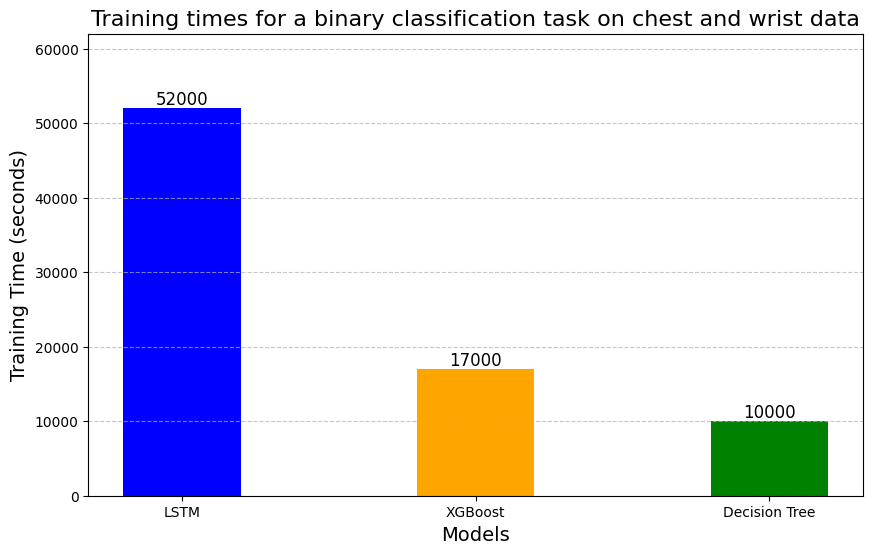

In [3]:
import matplotlib.pyplot as plt

# Define the models and their corresponding training times
models = ['LSTM', 'XGBoost', 'Decision Tree']
training_times = [52000, 17000, 10000]  # in seconds

# Create the bar graph with narrowed bars
plt.figure(figsize=(10, 6))
plt.bar(models, training_times, color=['blue', 'orange', 'green'], width=0.4)  # Adjust width here

# Add labels and title
plt.xlabel('Models', fontsize=14)
plt.ylabel('Training Time (seconds)', fontsize=14)
plt.title('Training times for a binary classification task on chest and wrist data', fontsize=16)
plt.ylim(0, max(training_times) + 10000)  # Set y-axis limit

# Show the values on top of the bars
for i, time in enumerate(training_times):
    plt.text(i, time + 500, str(time), ha='center', fontsize=12)

# Display the graph
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
